# GraphDrawing — тест пайплайна

Логика в [`tools/gd_experiments.py`](tools/gd_experiments.py). Зависимости: `pip install -r requirements.txt` (лучше в venv: `python3 -m venv .venv && source .venv/bin/activate`).

Импорт: в `sys.path` добавляется корень репозитория; **`importlib.reload`** нужен, чтобы после изменения `gd_experiments.py` не ловить «старый» модуль из памяти (иначе **Kernel → Restart**).

Таблица результатов: **`logRowAsPairs`** / **`styleLogPairsTable`** — два столбца «поле / значение»; для нескольких запусков подряд — **`logDfAsPairs(log_df)`**.

In [21]:
import importlib
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
if str(REPO) not in sys.path:
	sys.path.insert(0, str(REPO))

import gd_experiments as _g
importlib.reload(_g)

from gd_experiments import (
	METRIC_KEYS,
	appendLogRow,
	bestOfN,
	binaryPath,
	compileGd,
	logRowAsPairs,
	runGd,
	runRender,
	styleLogPairsTable,
)
from IPython.display import Image, display

print("binary:", binaryPath(REPO))

binary: /Users/user/Code/Repos/GraphDrawing/build/graph_drawing


In [22]:
compileGd(REPO)

-- Using the multi-header code from /Users/user/Code/Repos/GraphDrawing/build/_deps/nlohmann_json-src/include/
-- Configuring done (0.3s)
-- Generating done (0.0s)
-- Build files have been written to: /Users/user/Code/Repos/GraphDrawing/build
[100%] Built target graph_drawing


In [23]:
FLAGS = [
	"--graph",
	"SmallGraph",
	"--algo",
	"random",
	"--output",
	"out/notebook/notebook_1.json",
]

# Пример для far: ALGO_FLAGS = ["--C", "1.5", "--I", "200"]  или [] / не задавать => дефолты
ALGO_FLAGS = []

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/notebook_1.png


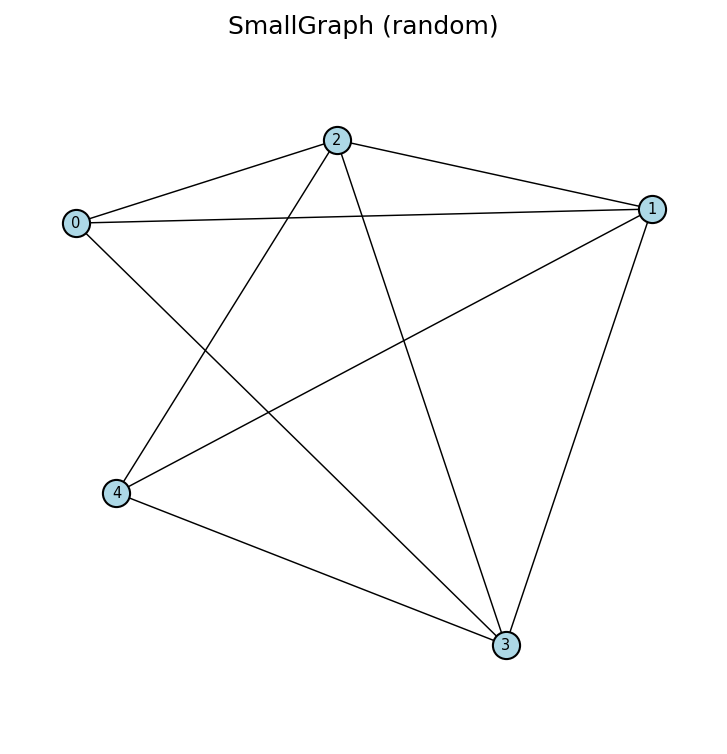

In [24]:
res = runGd(FLAGS, REPO, algo_flags=ALGO_FLAGS)
png = runRender(REPO, res["json_path"])
display(Image(filename=str(png)))

In [25]:
image_score = 4.0

log_df = None
log_df = appendLogRow(
	log_df,
	res["metrics"],
	image_score=image_score,
	argv_repr=res["argv_repr"],
	algo_flags_repr=res["algo_flags_repr"],
	stdin_repr=res["stdin_repr"],
	json_path=res["json_path"],
	png_path=png,
)
display(styleLogPairsTable(logRowAsPairs(log_df)))

поле,значение
volume,4928.07032
minVertexDist,35.506908
maxVertexDist,78.846427
avgVertexDist,58.300226
edgeCrossings,5
minAngle,0.240272
maxAngle,2.617261
density,0.0
image_score,4.0
argv_repr,--graph SmallGraph --algo random --output out/notebook/notebook_1.json


## Best-of-n по весам метрик

Одна мапа `WEIGHTS`: имя метрики → число. **Положительный вес** — чем больше метрика, тем лучше; **отрицательный** — чем меньше, тем лучше.

Опционально **`algoFlagsForRun(iters)`** — своя функция в ноутбуке: `iters` совпадает с `n` в `bestOfN`, внутри обычно `for i in range(iters): yield ...`. После исчерпания `yield` дальше подставляется общий `algo_flags`.

In [26]:
WEIGHTS = {k: 1.0 for k in METRIC_KEYS}

N = 5


def algoFlagsForRun(iters):
	for i in range(iters):
		yield ALGO_FLAGS


best, scores, all_runs = bestOfN(
	REPO,
	["--graph", "SmallGraph", "--algo", "random"],
	N,
	WEIGHTS,
	algo_flags=ALGO_FLAGS,
	algoFlagsForRun=algoFlagsForRun,
)
best["json_path"], scores

(PosixPath('/Users/user/Code/Repos/GraphDrawing/out/batch_runs/SmallGraph_random_batch_0.json'),
 [6.680434491592685,
  4.563386061551162,
  3.807307574668954,
  3.2989896555594513,
  3.2430377596041007])